# **Denetimsiz Öğrenme**

1. K means Clustering
2. Hierarchical Clustering
3. DBSCAN
4. Gaussian Mixture Model
5. Pca


In [2]:
# Temel kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#veri ön işleme
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


# Algoritmalar ( Kümeleme)
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

#Boyut indirme
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#Değerlendirme Metrikleri

from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score


from scipy.cluster.hierarchy import dendrogram, linkage


plt.rcParams['figure.figsize'] = [16, 10]
plt.rcParams['font.size'] = 14
sns.set_style('whitegrid')
print('Herşey hazır')




Herşey hazır


In [6]:
dosya_adi = '/CC GENERAL.csv'


df = pd.read_csv(dosya_adi)

print("🚀 Veri seti başarıyla yüklendi!")
print(f"Toplam Satır Sayısı: {df.shape[0]} | Toplam Sütun Sayısı: {df.shape[1]}")
print("-" * 50)
df.head()

🚀 Veri seti başarıyla yüklendi!
Toplam Satır Sayısı: 8950 | Toplam Sütun Sayısı: 18
--------------------------------------------------


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [8]:
data =pd.read_csv('/CC GENERAL.csv')
df=data.copy()

In [9]:
print(f'Veri Seti Boyutu: {df.shape}')
print(f'Sutun sayisi:{len(df.columns)}')
print(f'Satır Sayısı:{len(df)}')


Veri Seti Boyutu: (8950, 18)
Sutun sayisi:18
Satır Sayısı:8950


In [10]:
#veri seti bilgisi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [11]:
df.isnull().sum()


,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [12]:
#Istatıksel Ozet
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [13]:
print('Eksik değerler')
print('--'*50)
print(df.isnull().sum()[df.isnull().sum()>0])
print(f'toplam eksik değer: {df.isnull().sum().sum()}')
print('--'*50)

Eksik değerler
----------------------------------------------------------------------------------------------------
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64
toplam eksik değer: 314
----------------------------------------------------------------------------------------------------


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
df_columns =df.columns.str.strip()

In [15]:
df.set_index('CUST_ID', inplace=True)
imputer = SimpleImputer(strategy='mean')
df_imputed=pd.DataFrame(imputer.fit_transform(df),columns=df.columns, index=df.index)

print('Eksik değerler')
print('--'*50)
print(df_imputed.isnull().sum()[df_imputed.isnull().sum()>0])
print(f'toplam eksik değer: {df_imputed.isnull().sum().sum()}')

Eksik değerler
----------------------------------------------------------------------------------------------------
Series([], dtype: int64)
toplam eksik değer: 0


In [16]:
scaler= StandardScaler()
x_scaled=scaler.fit_transform(df_imputed)
x_scaled=pd.DataFrame(x_scaled,columns=df_imputed.columns,index=df_imputed.index)

print('Ölçeklenmiş veri seti')
print('--'*50)
x_scaled.head(2)

Ölçeklenmiş veri seti
----------------------------------------------------------------------------------------------------


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CUST_ID,,,,,,,,,,,,,,,,,
C10001,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960433,-0.528979,-0.310968,-0.525551,0.36068
C10002,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688639,0.818642,0.089310,0.234227,0.36068


In [17]:
df.head(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CUST_ID,,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.4,0.0,95.4,0.000000,0.166667,0.0,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
C10002,3202.467416,0.909091,0.0,0.0,0.0,6442.945483,0.000000,0.0,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12


## **K means**

Veri setini k adet kümeye ayıran bir algoritma

parametreleri:


*   n_Cluster küme sayısı
*   init  başlangıç seçme yöntemi
*   n_init farklı başlangıçlarla çalıştırma sayısı
*   max_iter maksimum iterasyon sayısı


Küme sayısı belirleme yöntemleri
*  elbow
* silhoutte
*  Davies Bouldin

✅ Veri başarıyla yüklendi, temizlendi ve 'X_scaled' olarak hazırlandı!
İşlenecek Veri Boyutu: (8950, 17)
------------------------------------------------------------
🔄 Algoritmalar test ediliyor, grafikler çiziliyor... Lütfen bekleyin...


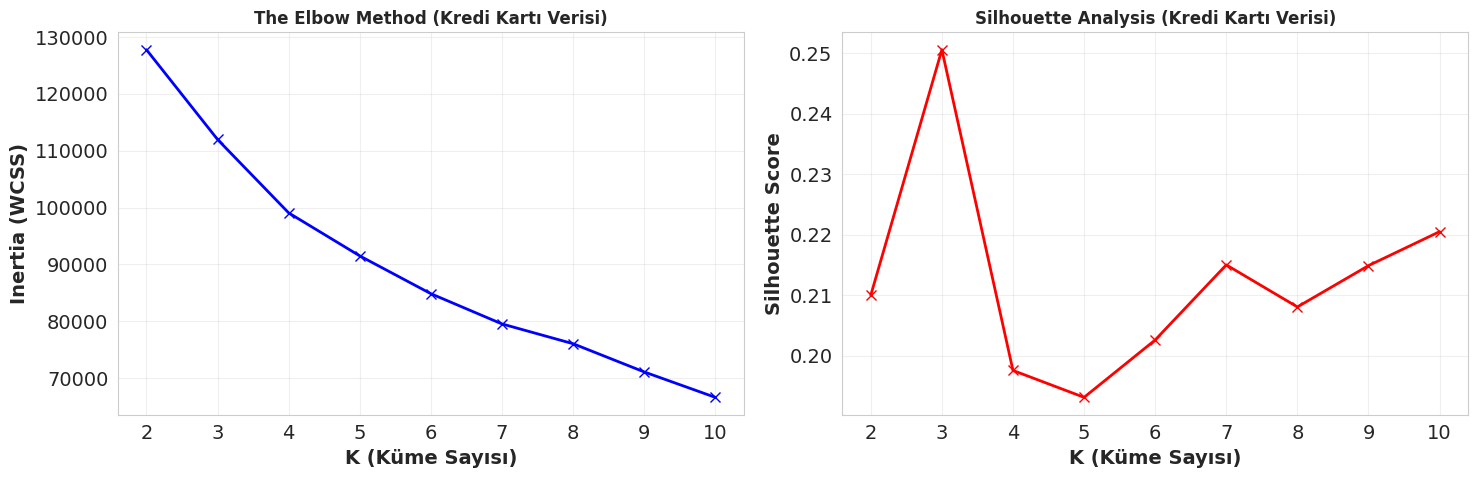

------------------------------------------------------------
📊 En yüksek Silhouette Skoru: 0.2506
🎯 Silhouette kriterine göre en ideal küme sayısı (K): 3
------------------------------------------------------------


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# =====================================================================
# 1. ADIM: VERİ SETİNİ YÜKLEME VE ÖN İŞLEME (SCALING)
# =====================================================================

# Veri setini content içinden okuyoruz
df = pd.read_csv('/CC GENERAL.csv')

# K-Means metinsel ifadeleri anlayamaz, bu yüzden CUST_ID sütununu eliyoruz
X = df.drop(columns=['CUST_ID'])

X = X.fillna(X.mean())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Veri başarıyla yüklendi, temizlendi ve 'X_scaled' olarak hazırlandı!")
print(f"İşlenecek Veri Boyutu: {X_scaled.shape}")
print("-" * 60)

# =====================================================================
# 2. ADIM: ELBOW VE SILHOUETTE ANALİZİ
# =====================================================================

inertia = []
silhouette_scores = []
K_range = range(2, 11)  # Küme sayılarını 2 ile 10 arasında deniyoruz

print("🔄 Algoritmalar test ediliyor, grafikler çiziliyor... Lütfen bekleyin...")

for k in K_range:
    # n_init=10 ekleyerek güncel sklearn uyarılarını engelliyoruz
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# =====================================================================
# 3. ADIM: GÖRSELLEŞTİRME
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sol Grafik: Elbow Method (Dirsek Yöntemi)
axes[0].plot(K_range, inertia, 'bx-', linewidth=2, markersize=7)
axes[0].set_xlabel('K (Küme Sayısı)', fontweight='bold')
axes[0].set_ylabel('Inertia (WCSS)', fontweight='bold')
axes[0].set_title('The Elbow Method (Kredi Kartı Verisi)', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Sağ Grafik: Silhouette Score (Siluet Analizi)
axes[1].plot(K_range, silhouette_scores, 'rx-', linewidth=2, markersize=7)
axes[1].set_xlabel('K (Küme Sayısı)', fontweight='bold')
axes[1].set_ylabel('Silhouette Score', fontweight='bold')
axes[1].set_title('Silhouette Analysis (Kredi Kartı Verisi)', fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# En iyi K değerini ekrana yazdırıyoruz
optimal_k = K_range[np.argmax(silhouette_scores)]
print("-" * 60)
print(f'📊 En yüksek Silhouette Skoru: {max(silhouette_scores):.4f}')
print(f'🎯 Silhouette kriterine göre en ideal küme sayısı (K): {optimal_k}')
print("-" * 60)


In [20]:

# Gerekli tüm metrik fonksiyonlarını içeri aktarıyoruz
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

# Optimum K değerini belirliyoruz
optimal_k = 4

# K-Means modelini oluşturup eğitiyoruz
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# ÇÖZÜM: Küçük 'x_scaled' yerine yukarıda oluşturduğumuz Büyük 'X_scaled' matrisini verdik
kmeans_labels = kmeans.fit_predict(X_scaled)

print('📊 K-means Kümeleme Sonuçları (Kredi Kartı Verisi):')
print("-" * 50)
print(f'Küme sayısı: {optimal_k}')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, kmeans_labels):.4f}')
print(f'Davies Bouldin Skoru: {davies_bouldin_score(X_scaled, kmeans_labels):.4f}')
print(f'Calinski Harabasz Skoru: {calinski_harabasz_score(X_scaled, kmeans_labels):.4f}')
print("-" * 50)
print(f'👥 Küme Dağılımı (Müşteri Sayıları):')

# Sonuçları ekrana düzgün bastırmak için index bazlı sıralıyoruz
print(pd.Series(kmeans_labels).value_counts().sort_index())

📊 K-means Kümeleme Sonuçları (Kredi Kartı Verisi):
--------------------------------------------------
Küme sayısı: 4
Silhouette Skoru: 0.1976
Davies Bouldin Skoru: 1.5752
Calinski Harabasz Skoru: 1597.5222
--------------------------------------------------
👥 Küme Dağılımı (Müşteri Sayıları):
0    3367
1     409
2    1198
3    3976
Name: count, dtype: int64


In [21]:
# 1. Küme etiketlerini (labels) orijinal ana veri setimize (df) yeni bir sütun olarak ekliyoruz
df['KMeans_Cluster'] = kmeans_labels

# 2. CUST_ID sütunu metinsel (string) olduğu için matematiksel ortalaması alınamaz.
# Gelecekte hata/uyarı almamak için onu düşürüp (drop), kümelerin sayısal ortalamasını hesaplıyoruz.
cluster_summary = df.drop(columns=['CUST_ID']).groupby('KMeans_Cluster').mean().round(2)

print('📊 K-Means Müşteri Küme Profilleri (Sütun Ortalamaları):')
print("-" * 60)

# Colab hücresinin en altında direkt değişken adını yazarsan sana Excel gibi çok şık bir tablo basar
cluster_summary

📊 K-Means Müşteri Küme Profilleri (Sütun Ortalamaları):
------------------------------------------------------------


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
KMeans_Cluster,,,,,,,,,,,,,,,,,
0,894.91,0.93,1236.18,593.97,642.48,210.57,0.89,0.30,0.71,0.04,0.79,22.09,4213.21,1332.19,646.02,0.27,11.59
1,3551.15,0.99,7681.62,5095.88,2587.21,653.64,0.95,0.74,0.79,0.07,2.09,89.36,9696.94,7288.74,1985.04,0.29,11.95
2,4602.46,0.97,501.90,320.37,181.61,4520.72,0.29,0.14,0.19,0.48,14.28,7.66,7546.96,3481.15,2020.80,0.03,11.39
3,1011.75,0.79,269.97,209.85,60.39,595.76,0.17,0.09,0.08,0.11,2.13,2.90,3277.40,974.51,569.00,0.08,11.45


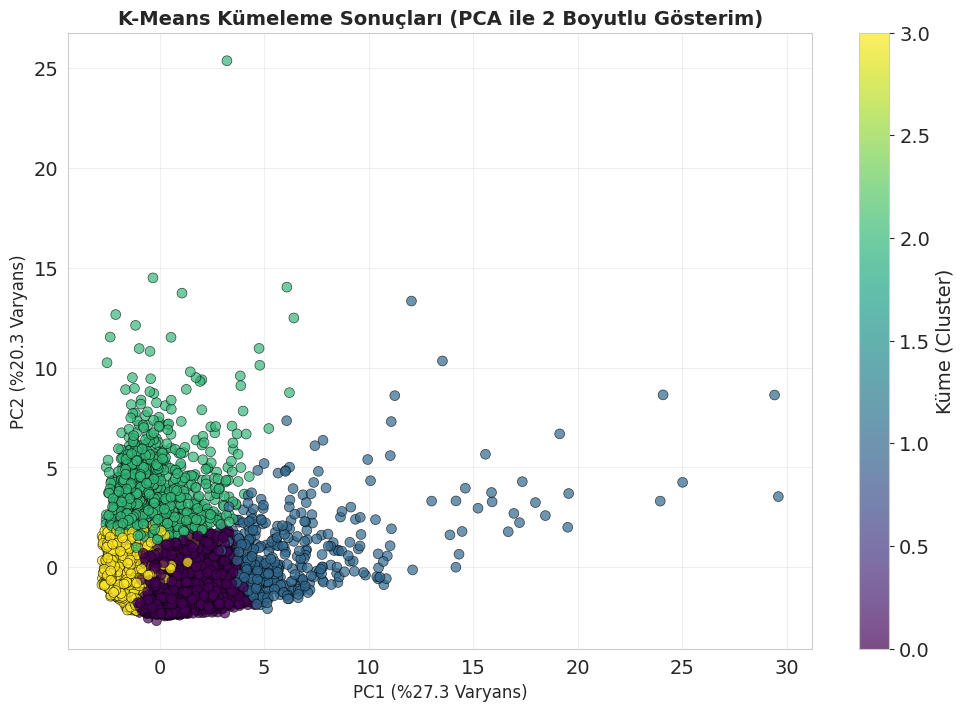

In [22]:


# =====================================================================
# PCA İLE BOYUT İNDİRGEME VE K-MEANS GÖRSELLEŞTİRMESİ
# =====================================================================

# 1. PCA modelini tanımlıyoruz (17 boyuttan 2 ana bileşene indirgeme yapıyoruz)
pca = PCA(n_components=2, random_state=42)

# ÇÖZÜM: Küçük 'x_scaled' yerine büyük 'X_scaled' matrisini veriyoruz
X_pca = pca.fit_transform(X_scaled)

# 2. Grafik alanını oluşturuyoruz
plt.figure(figsize=(12, 8))

# İndirgenmiş 2 boyutlu uzayda (PC1 ve PC2) noktaları çizdiriyoruz
# Noktaların renkleri (c=kmeans_labels) bir önceki adımda bulduğumuz kümelere göre belirleniyor
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)

# Sağ tarafa hangi rengin hangi kümeye (0, 1, 2, 3) ait olduğunu gösteren renk barı ekliyoruz
plt.colorbar(scatter, label='Küme (Cluster)')

# Grafik başlık ve eksen isimleri
# Eksenlerdeki yüzde ifadeleri, bu iki bileşenin toplam verinin yüzde kaçını temsil ettiğini gösterir
plt.title('K-Means Kümeleme Sonuçları (PCA ile 2 Boyutlu Gösterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} Varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} Varyans)', fontsize=12)
plt.grid(True, alpha=0.3)

# Grafiği ekrana basıyoruz
plt.show()

# **Hiyerarşik kümeleme**

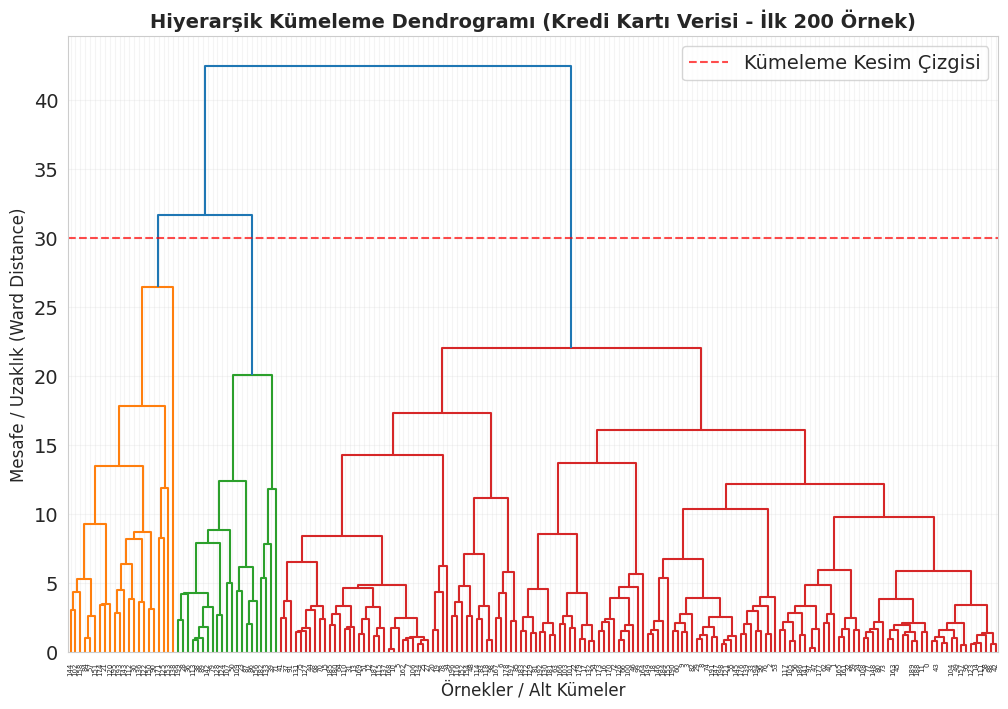

In [23]:

# =====================================================================
# HİYERARŞİK KÜMELEME VE DENDROGRAM GÖRSELLEŞTİRMESİ
# =====================================================================

plt.figure(figsize=(12, 8))

# 1. Ward metodu kullanarak hiyerarşik bağları (linkage) hesaplıyoruz
# Verinin çok kalabalık olup grafiği bozmaması için ilk 200 örneği [:200] alıyoruz
# ÇÖZÜM: Küçük 'x_scaled' yerine büyük 'X_scaled' matrisini verdik
linked = linkage(X_scaled[:200], method='ward')

# 2. Dendrogram şemasını çizdiriyoruz
# p=10 ve truncate_mode='level' ile grafiğin çok fazla dallanıp boğulmasını engelliyoruz
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False,
           truncate_mode='level',
           p=10)

# Grafik başlık ve eksen isimlendirmeleri
plt.title('Hiyerarşik Kümeleme Dendrogramı (Kredi Kartı Verisi - İlk 200 Örnek)', fontsize=14, fontweight='bold')
plt.xlabel('Örnekler / Alt Kümeler', fontsize=12)
plt.ylabel('Mesafe / Uzaklık (Ward Distance)', fontsize=12)

# 3. Kümeleri kaç parçaya böleceğimizi belirleyen yatay kesim çizgisi
# Ward yönteminde mesafe ölçeği değişebileceği için başlangıçta y=30 çizgisi ideal bir referanstır
plt.axhline(y=30, color='r', linestyle='--', alpha=0.7, label='Kümeleme Kesim Çizgisi')

plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [24]:
# Küme sayısını ve bağlantı yöntemini belirliyoruz
optimal_k = 4
baglanti_yontemi = 'ward'

# Hiyerarşik (Agglomerative) modeli tanımlıyoruz
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage=baglanti_yontemi)

# ÇÖZÜM: Küçük 'x_scaled' yerine veri setimize ait büyük 'X_scaled' matrisini verdik
agg_labels = agg_clustering.fit_predict(X_scaled)

print('📊 Hiyerarşik (Agglomerative) Kümeleme Sonuçları (CC General):')
print("-" * 55)
print(f'Kümeleme Sayısı : {optimal_k}')
print(f'Bağlantı Yöntemi : {baglanti_yontemi}')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, agg_labels):.4f}')
print(f'Davies Bouldin Skoru: {davies_bouldin_score(X_scaled, agg_labels):.4f}')
print(f'Calinski Harabasz Skoru: {calinski_harabasz_score(X_scaled, agg_labels):.4f}')
print("-" * 55)
print(f'👥 Küme Dağılımı (Müşteri Sayıları):')

# Kümelere kaçar müşteri düştüğünü sıralı olarak basıyoruz
print(pd.Series(agg_labels).value_counts().sort_index())


📊 Hiyerarşik (Agglomerative) Kümeleme Sonuçları (CC General):
-------------------------------------------------------
Kümeleme Sayısı : 4
Bağlantı Yöntemi : ward
Silhouette Skoru: 0.1547
Davies Bouldin Skoru: 1.7762
Calinski Harabasz Skoru: 1255.6049
-------------------------------------------------------
👥 Küme Dağılımı (Müşteri Sayıları):
0     487
1    4668
2     864
3    2931
Name: count, dtype: int64


In [25]:
# 1. K-Means modelinden elde edilen küme etiketlerini (labels) orijinal ana veri setimize ekliyoruz
df['KMeans_Cluster'] = kmeans_labels

# 2. CUST_ID sütunu metinsel (string) olduğu için matematiksel ortalaması alınamaz.
# Hata almamak için bu sütunu drop ediyor ve kümelerin sütun bazlı ortalamalarını hesaplıyoruz.
cluster_summary = df.drop(columns=['CUST_ID']).groupby('KMeans_Cluster').mean().round(2)

print('📊 K-Means Kredi Kartı Müşteri Küme Profilleri:')
print("-" * 65)

# Colab hücresinin en son satırına direkt değişkeni yazarsak bize çok düzenli bir Excel tablosu sunar
cluster_summary

📊 K-Means Kredi Kartı Müşteri Küme Profilleri:
-----------------------------------------------------------------


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
KMeans_Cluster,,,,,,,,,,,,,,,,,
0,894.91,0.93,1236.18,593.97,642.48,210.57,0.89,0.30,0.71,0.04,0.79,22.09,4213.21,1332.19,646.02,0.27,11.59
1,3551.15,0.99,7681.62,5095.88,2587.21,653.64,0.95,0.74,0.79,0.07,2.09,89.36,9696.94,7288.74,1985.04,0.29,11.95
2,4602.46,0.97,501.90,320.37,181.61,4520.72,0.29,0.14,0.19,0.48,14.28,7.66,7546.96,3481.15,2020.80,0.03,11.39
3,1011.75,0.79,269.97,209.85,60.39,595.76,0.17,0.09,0.08,0.11,2.13,2.90,3277.40,974.51,569.00,0.08,11.45


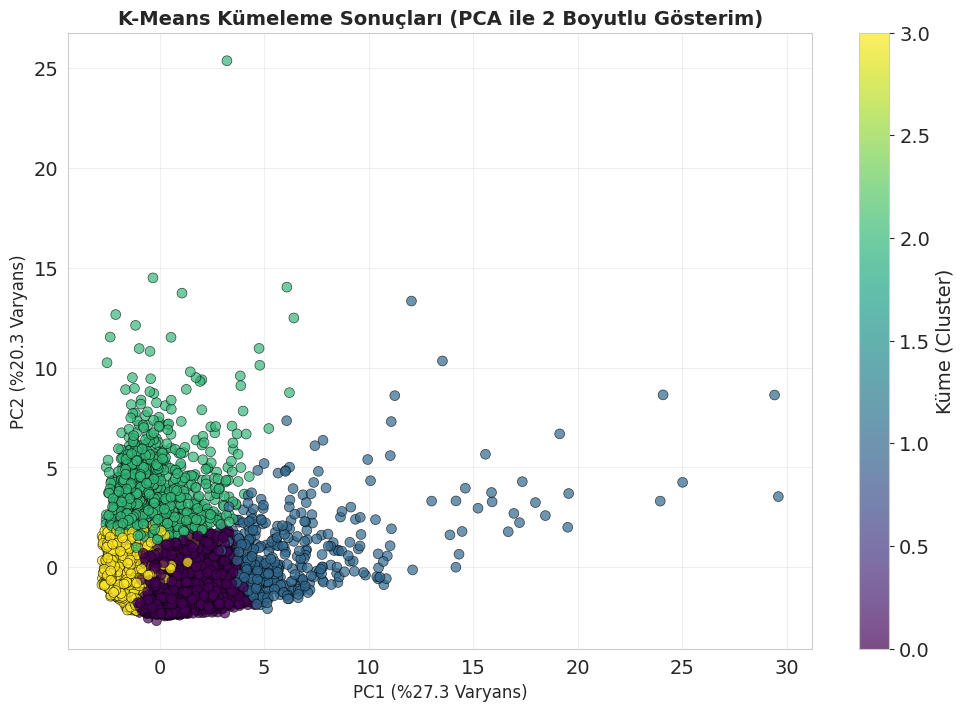

In [26]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# =====================================================================
# PCA İLE BOYUT İNDİRGEME VE K-MEANS GÖRSELLEŞTİRMESİ (CC GENERAL)
# =====================================================================

# 1. PCA modelini tanımlıyoruz (17 boyuttan 2 ana bileşene düşürüyoruz)
pca = PCA(n_components=2, random_state=42)

# ÇÖZÜM: Küçük 'x_scaled' yerine ana veri setimize ait büyük 'X_scaled' matrisini verdik
X_pca = pca.fit_transform(X_scaled)

# 2. Grafik alanını oluşturuyoruz
plt.figure(figsize=(12, 8))

# İndirgenmiş 2 boyutlu uzayda noktaları çizdiriyoruz
# Noktaların renkleri (c=kmeans_labels) K-Means modelinin tahmin ettiği kümelere göredir
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)

# Sağ tarafa hangi rengin hangi kümeye (0, 1, 2, 3) ait olduğunu gösteren renk barı ekliyoruz
plt.colorbar(scatter, label='Küme (Cluster)')

# Grafik başlık ve eksen isimleri (Açıklanan varyans yüzdelerini otomatik hesaplar)
plt.title('K-Means Kümeleme Sonuçları (PCA ile 2 Boyutlu Gösterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} Varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} Varyans)', fontsize=12)
plt.grid(True, alpha=0.3)

# Grafiği ekrana basıyoruz
plt.show()

## **Dbscan**


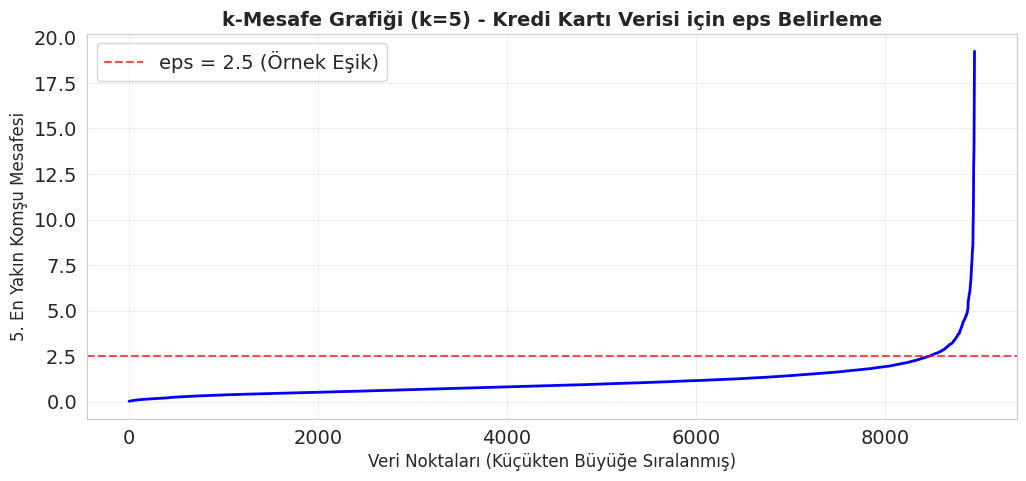

In [27]:

from sklearn.neighbors import NearestNeighbors

# =====================================================================
# DBSCAN İÇİN OPTİMUM EPS DEĞERİ BELİRLEME (k-DISTANCE GRAPH)
# =====================================================================

# 1. 5 en yakın komşuyu hesaplayacak modeli tanımlıyoruz (Genelde boyut sayısı veya min_samples seçilir)
neighbors = NearestNeighbors(n_neighbors=5)

# ÇÖZÜM: Küçük 'x_scaled' yerine veri setimize ait büyük 'X_scaled' matrisini verdik
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# 2. Her noktanın 5. en yakın komşusuna olan mesafesini alıp küçükten büyüğe sıralıyoruz
distances = np.sort(distances[:, 4], axis=0)

# 3. Görselleştirme
plt.figure(figsize=(12, 5))
plt.plot(distances, 'b-', linewidth=2)

# Grafik başlık ve eksen isimleri
plt.title('k-Mesafe Grafiği (k=5) - Kredi Kartı Verisi için eps Belirleme', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktaları (Küçükten Büyüğe Sıralanmış)', fontsize=12)
plt.ylabel('5. En Yakın Komşu Mesafesi', fontsize=12)

# Referans kesim çizgisi (Grafiği çalıştırdıktan sonra kırılma yerine göre y=2.5 değerini güncelleyebilirsin)
plt.axhline(y=2.5, color='r', linestyle='--', alpha=0.7, label='eps = 2.5 (Örnek Eşik)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:

# DBSCAN sınıfını içeri aktarıyoruz
from sklearn.cluster import DBSCAN
# Metrik fonksiyonlarını import ediyoruz
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

# =====================================================================
# DBSCAN KÜMELEME UYGULAMASI (CC GENERAL)
# =====================================================================

# Bir önceki adımdaki k-Mesafe grafiğine göre belirlenen eps=2.5 ve min_samples=5 ile modeli kuruyoruz
dbscan = DBSCAN(eps=2.5, min_samples=5)

# ÇÖZÜM: Küçük 'x_scaled' yerine veri setimize ait büyük 'X_scaled' matrisini verdik
dbscan_labels = dbscan.fit_predict(X_scaled)

# Küme sayısını hesaplama (Gürültü olan -1 değerini küme sayısından düşüyoruz)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
# Toplam gürültü (aykırı değer) sayısını bulma
n_noise = list(dbscan_labels).count(-1)

print('📊 DBSCAN Kümeleme Sonuçları (Kredi Kartı Verisi):')
print("-" * 55)
print(f'Bulunan Küme Sayısı : {n_clusters_db}')
print(f'Gürültü (Aykırı) Sayısı: {n_noise}')
print(f'Gürültü Oranı : %{n_noise/len(dbscan_labels)*100:.2f}')
print("-" * 55)

# AKADEMİK PÜF NOKTASI: Metrikleri sadece gürültü olmayan (gerçek kümelere ait) noktalar için hesaplıyoruz
if n_clusters_db > 1:
    # Sadece etiketleri -1 olmayan verileri seçiyoruz
    non_noise_mask = dbscan_labels != -1
    X_filtered = X_scaled[non_noise_mask]
    labels_filtered = dbscan_labels[non_noise_mask]

    print(f'Silhouette Skoru (Gürültüsüz): {silhouette_score(X_filtered, labels_filtered):.4f}')
    print(f'Davies Bouldin Skoru (Gürültüsüz): {davies_bouldin_score(X_filtered, labels_filtered):.4f}')
    print(f'Calinski Harabasz Skoru (Gürültüsüz): {calinski_harabasz_score(X_filtered, labels_filtered):.4f}')
else:
    print("⚠️ Metrikler hesaplanamadı: Yeterli sayıda küme oluşmadı veya tüm noktalar gürültü ilan edildi.")

print("-" * 55)
print(f'👥 Küme Dağılımı (Müşteri Sayıları):')
# -1 değeri gürültü kitleyi, diğer rakamlar ise oluşan gerçek kümeleri gösterir
print(pd.Series(dbscan_labels).value_counts().sort_index())

📊 DBSCAN Kümeleme Sonuçları (Kredi Kartı Verisi):
-------------------------------------------------------
Bulunan Küme Sayısı : 1
Gürültü (Aykırı) Sayısı: 341
Gürültü Oranı : %3.81
-------------------------------------------------------
⚠️ Metrikler hesaplanamadı: Yeterli sayıda küme oluşmadı veya tüm noktalar gürültü ilan edildi.
-------------------------------------------------------
👥 Küme Dağılımı (Müşteri Sayıları):
-1     341
 0    8609
Name: count, dtype: int64


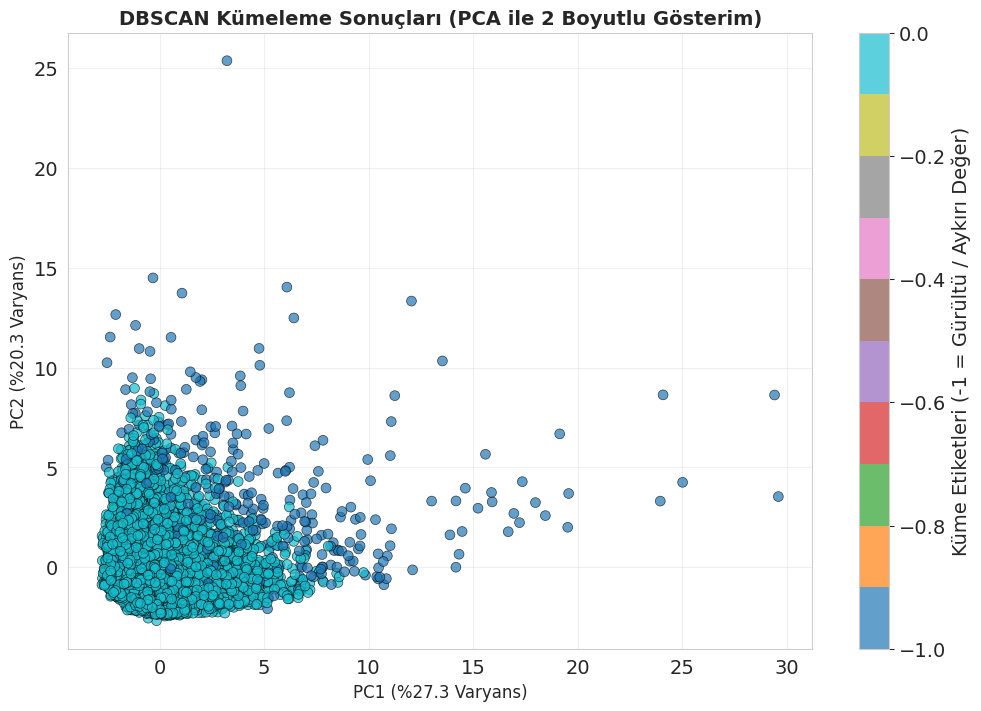

In [29]:


# =====================================================================
# DBSCAN KÜMELEME SONUÇLARININ PCA İLE GÖRSELLEŞTİRİLMESİ
# =====================================================================

plt.figure(figsize=(12, 8))

# 2 boyutlu PCA uzayında noktaları çizdiriyoruz.
# Renklendirmeyi DBSCAN etiketlerine (c=dbscan_labels) göre yapıyoruz.
# 'tab10' veya 'Set1' gibi kesikli renk haritaları DBSCAN için çok uygundur.
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)

# Sağ tarafa hangi rengin hangi kümeye ait olduğunu gösteren renk barı
# DBSCAN'de -1 değeri alan noktaların gürültü (aykırı değer) olduğunu belirtiyoruz
plt.colorbar(scatter, label='Küme Etiketleri (-1 = Gürültü / Aykırı Değer)')

# Grafik başlık ve eksen isimleri (Açıklanan varyans yüzdelerini otomatik çeker)
plt.title('DBSCAN Kümeleme Sonuçları (PCA ile 2 Boyutlu Gösterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} Varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} Varyans)', fontsize=12)
plt.grid(True, alpha=0.3)

# Grafiği ekrana basıyoruz
plt.show()

# **Gaussian Mixture Model**

hiperparametreleri

* n_components: bileşen küme sayısı
* covariance_type:kovaryans tipi
* max_iter: maksimum iterasyon sayısı



In [30]:


# Küme sayısını belirliyoruz
optimal_k = 4

# GMM modelini tanımlıyoruz (Aşırı uyarılara engel olmak için random_state ekledik)
gmm = GaussianMixture(n_components=optimal_k, covariance_type='full', max_iter=200, random_state=42)

# ÇÖZÜM: Küçük 'x_scaled' yerine veri setimize ait büyük 'X_scaled' matrisini verdik
gmm_labels = gmm.fit_predict(X_scaled)
gmm_probs = gmm.predict_proba(X_scaled)

print('📊 GMM (Gaussian Mixture Model) Kümeleme Sonuçları (CC General):')
print("-" * 55)
print(f'Kümeleme Sayısı : {optimal_k}')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, gmm_labels):.4f}')
print(f'Davies Bouldin Skoru: {davies_bouldin_score(X_scaled, gmm_labels):.4f}')
print(f'Calinski Harabasz Skoru: {calinski_harabasz_score(X_scaled, gmm_labels):.4f}')
print("-" * 55)
print(f'👥 Küme Dağılımı (Müşteri Sayıları):')

# Kümelere kaçar müşteri düştüğünü sıralı olarak basıyoruz
print(pd.Series(gmm_labels).value_counts().sort_index())

📊 GMM (Gaussian Mixture Model) Kümeleme Sonuçları (CC General):
-------------------------------------------------------
Kümeleme Sayısı : 4
Silhouette Skoru: 0.0733
Davies Bouldin Skoru: 2.7770
Calinski Harabasz Skoru: 738.5114
-------------------------------------------------------
👥 Küme Dağılımı (Müşteri Sayıları):
0    2077
1    1697
2    2484
3    2692
Name: count, dtype: int64


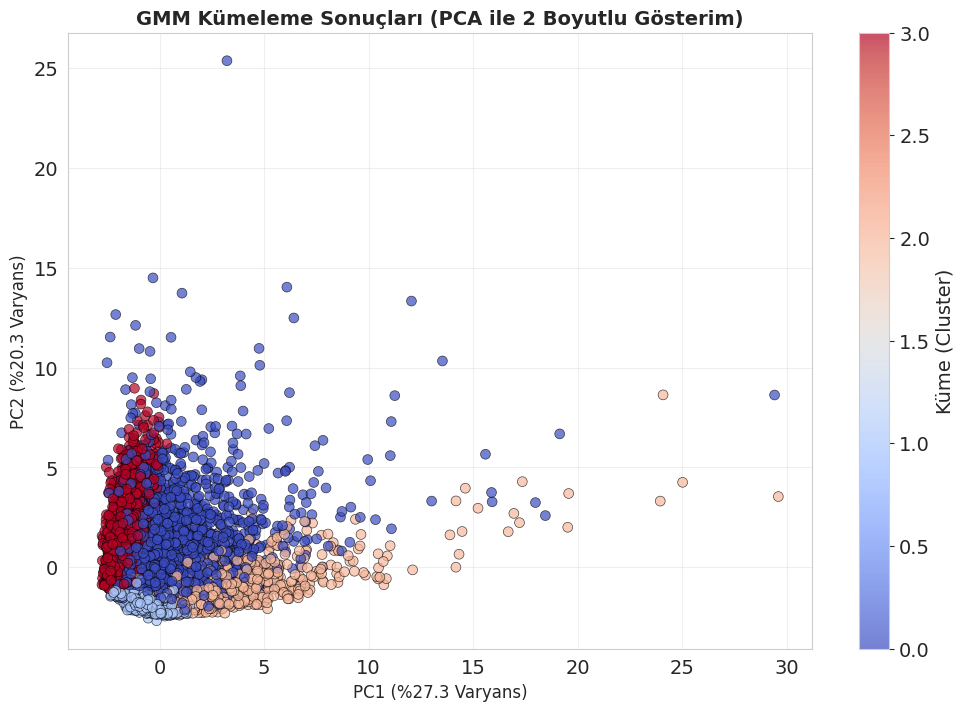

In [31]:

# =====================================================================
# GMM KÜMELEME SONUÇLARININ PCA İLE GÖRSELLEŞTİRİLMESİ (CC GENERAL)
# =====================================================================

plt.figure(figsize=(12, 8))

# 2 boyutlu PCA uzayında noktaları çizdiriyoruz.
# Renklendirmeyi GMM modelinin atadığı küme etiketlerine (c=gmm_labels) göre yapıyoruz.
# 'coolwarm', 'viridis' veya 'plasma' renk haritaları GMM görselleştirmesine çok yakışır.
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='coolwarm',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)

# Sağ tarafa hangi rengin hangi kümeye (0, 1, 2, 3) ait olduğunu gösteren renk barı ekliyoruz
plt.colorbar(scatter, label='Küme (Cluster)')

# Grafik başlık ve eksen isimleri (Açıklanan varyans yüzdelerini otomatik çeker)
plt.title('GMM Kümeleme Sonuçları (PCA ile 2 Boyutlu Gösterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} Varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} Varyans)', fontsize=12)
plt.grid(True, alpha=0.3)

# Grafiği ekrana basıyoruz
plt.show()